# Analiza danych przestrzennych - ćwiczenia laboratoryjne 2025/2026

Ten notatnik zalicza się do grupy zestawów zadań, na podstawie których odbywa się zaliczenie ćwiczeń i podlega zwrotowi do oceny w ustalonym na zajęciach terminie.

Uwagi i wytyczne ogólne dotyczące uzupełniania i oceny notatnika:
- Podczas wykonywania zadań należy korzystać wyłącznie z pakietów zaimportowanych na początku notatnika oraz z pakietów wchodzących w skład standardowej biblioteki Pythona, które można zaimportować samodzielnie we wskazanej komórce notatnika.
- Swoje rozwiązania należy wprowadzać wyłącznie w miejce następujących fragmentów kodu:<br/> `# YOUR CODE HERE`<br/> `raise NotImplementedError()`<br/> 
a odpowiedzi tekstowe w komórkach oznaczonych hasłem:<br/> 
`YOUR ANSWER HERE`<br/> 
Nie należy w żaden sposób modyfikować pozostałych fragmentów kodu oraz innych elementów notatnika, w szczególności dodawać lub usuwać komórek oraz zmieniać nazwy pliku.
- Jeżeli zestaw zadań wymaga skorzystania z fragmentów kodu opracowanego w ramach wcześniejszych zestawów zadań należy je umieścić we wskazanej komórce notatnika.
- Otrzymywane wyniki i odpowiedzi mają być rezultatem wykonania napisanego kodu, odpowiedzi uzupełniane manualnie nie podlegają ocenie.
- Zawarte w notatniku automatyczne testy mają charakter poglądowy. Dotyczą one wybranych aspektów zadań i mają na celu wyłapać podstawowe błędy. Przejście przez kod wszystkich testów nie oznacza, że zadanie jest wykonane w całości poprawnie i zostanie ocenione na maksymalną liczbę punktów.
- Zadania należy wykonać w taki sposób, aby podczas wykonywania kodu nie zostały wyświetlone żadne ostrzeżenia.
- Zadania, które powodują wyświetlenie komunikatu o błędzie przerywającym wykonywanie kodu nie podlegają ocenie.
- W treści niektórych zadań mogą znaleźć się przykładowe schematy ich rozwiązania lub przykładowe schematy istotnych części rozwiązania. Nie zawsze są to rozwiązania optymalne pod kątem długości kodu lub prostoty rozwiązania.  Ich celem jest klarowne rozbicie pracy na kroki i ułatwienie samodzielnej weryfikacji wyników na każdym etapie. Należy je traktować wyłącznie poglądowo, a nie jako jedyne dopuszczalne rozwiązania. Ocenie podlega poprawność merytoryczna rozwiązania, jego kompletność oraz zgodność z wymaganiami, a nie konkretna forma zapisu.
- Dla zachowania przejrzystości i łatwego odnajdywania informacji w treści zadań podawane są pełne nazwy funkcji i klas wraz z nazwami pakietów (np. `pandas.read_csv()`, `geopandas.GeoDataFrame.to_crs`). W notatniku te same obiekty są dostępne przez skrótowe aliasy (np. `pd.read_csv()`, `gpd.GeoDataFrame.to_crs`).

Uwagi i wytyczne ogólne dotyczące wizualizacji wyników:
- Wszystkie wykresy powinny być wykonane w jednolitym, przejrzystym i czytelnym stylu, posiadać odpowiednio dobrane proporcje i zakresy wartości osi.
- Figury powinny mieć ustawione białe tło, tak, aby niezależnie od ustawień notatnika wszystkie elementy wykresów były dobrze widoczne (domyślnie tło jest przeźroczyste co może powodować problemy w notatnikach z ustawionym ciemnym tłem). Rozmiar poziomy figur nie powinien przekraczać 20 cali.
- Wykresy oraz ich osie powinny mieć nadane tytuły. Jeżeli w obrębie figury znajduje się więcej niż jeden wykres to figura również powinna mieć nadany tytuł.

Przed odesłaniem zestawu zadań do oceny proszę uzupełnić komórkę z danymi autorów rozwiązania (nazwa zespołu oraz imiona, nazwiska i numery indeksów członków zespołu) oraz upewnić się, że notatnik działa zgodnie z oczekiwaniami. W tym celu należy skorzystać z opcji **Restart Kernel and Run All Cells...** dostępnej na górnej belce notatnika pod symbolem $\blacktriangleright\blacktriangleright$.

Nazwa zespołu:
Członkowie:

---

## Zestaw zadań 6: Generowanie procesów punktowych

In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

In [2]:
# Miejsce do importu pakietów wchodzących w skład standardowej biblioteki Pythona oraz ustawienie opcji wykorzystywanych pakietów

### Dane do zadań

In [3]:
poland = gpd.read_file("data.gpkg", layer='poland')
poland

,Nazwa,geometry
0,Polska,"POLYGON ((495817.822 183473.276, 495778.757 18..."


### Uwagi do wykonania zadań
We wszystkich zadaniach należy przyjąć, że pracujemy w płaskim układzie współrzędnych (układzie odniesienia opartym na odwzorowaniu kartograficznym na płaszczyznę). Dołączona do zestawu zadań tablica z granicami Polski zapisana jest w układzie EPSG:2180.

### Zadanie 1: Proces regularny z komponentem losowym [7 pkt]

Przygotuj funkcję `regular_pp()`, która będzie generować proces regularny z komponentem losowym w obrębie zadanego poligonu.

Algorytm postępowania:
1. Za pomocą własności `shapely.geometry.polygon.Polygon.bounds` odczytaj zakres współrzędnych poligonu, w obrębie którego ma być wygenerowany rozkład.

2. Korzystając z odczytanych zakresów współrzędnych, oblicz rozmiar komórki siatki ($d_x$ w poziomie i $d_y$ w pionie), dzieląc długość zakresu współrzędnych przez wartość określającą liczbę punktów siatki na danej osi.

3. Wygeneruj równomierne współrzędne środków komórek przy użyciu funkcji `numpy.linspace()` lub `numpy.arange()`, tak aby kolejne punkty były oddalone o $d_x$ i $d_y$, a skrajne punkty były odsunięte od granic obszaru o $\tfrac{1}{2} d_x$ i $\tfrac{1}{2} d_y$.

4. Utwórz dwuwymiarową siatkę współrzędnych $x$ i $y$ za pomocą funkcji `numpy.meshgrid()`, a następnie spłaszcz powstałe macierze z wykorzystaniem funkcji `numpy.ndarray.flatten()`.

5. Dodaj do współrzędnych każdego punktu unikalny komponent losowy określony wzorem $r \cdot rand$, gdzie:
   - $r$ – parametr określający wielkość komponentu losowego,  
   - $rand$ – wartość wylosowana z rozkładu jednostajnego:
     - dla współrzędnej $x$: z przedziału $\left[-\tfrac{1}{2} d_x,\, \tfrac{1}{2} d_x\right]$,  
     - dla współrzędnej $y$: z przedziału $\left[-\tfrac{1}{2} d_y,\, \tfrac{1}{2} d_y\right]$.  

   Do generowania wartości losowych użyj funkcji `numpy.random.rand()` lub `scipy.stats.uniform.rvs()`.

6. Utwórz geometrię punktową za pomocą funkcji `geopandas.points_from_xy()` na podstawie przygotowanych współrzędnych.

7. Zbuduj obiekt `geopandas.GeoDataFrame`, ustawiając kolumnę geometrii oraz przypisując właściwy układ odniesienia.

8. Skorzystaj z funkcji `geopandas.GeoSeries.within()` w celu odfiltrowania punktów znajdujących się poza obszarem poligonu. Pamiętaj o zresetowaniu indeksów wynikowej tablicy.

9. Zwróć tablicę zawierającą punkty położone wewnątrz poligonu.

In [17]:
def regular_pp(polygon, crs, grid, random_component):
    """
    Parameters
    -------
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego mają zostać wygenerowane punkty.
    crs: str, int, pyproj.crs.crs.CRS
        Układ odniesienia przypisany do wynikowego GeoDataFrame. Powinien odpowiadać układowi współrzędnych wejściowego poligonu.
    grid: list
        Lista określająca liczbę punktów w siatce w poziomie i w pionie.
        Przykład: [20, 10]
    random_component: float
        Liczba z przedziału [0, 1] określająca wielkość komponentu losowego.

    Returns
    -------
    points : geopandas.GeoDataFrame
        Tablica zawierająca punkty w układzie odniesienia `crs`, ograniczone wyłącznie do obszaru wejściowego poligonu.
    """
    minx, miny, maxx, maxy = polygon.bounds

    dx = (maxx - minx)/grid[0]
    dy = (maxy - miny)/grid[1]

    x_sr = np.arange(minx + 0.5*dx, maxx + 0.5*dx, dx)
    y_sr = np.arange(miny + 0.5*dy, maxy + 0.5*dy, dy)

    X, Y = np.meshgrid(x_sr, y_sr)

    x = X.flatten()
    y = Y.flatten()

    xx = (np.random.rand(len(x)) - 0.5)*dx*random_component
    yy = (np.random.rand(len(y)) - 0.5)*dy*random_component

    x = x + xx
    y = y + yy

    geometry = gpd.points_from_xy(x,y)
    GPD = gpd.GeoDataFrame(geometry=geometry, crs=crs)

    mask = GPD.within(polygon)

    df = GPD[mask].reset_index(drop=True)

    return df
    


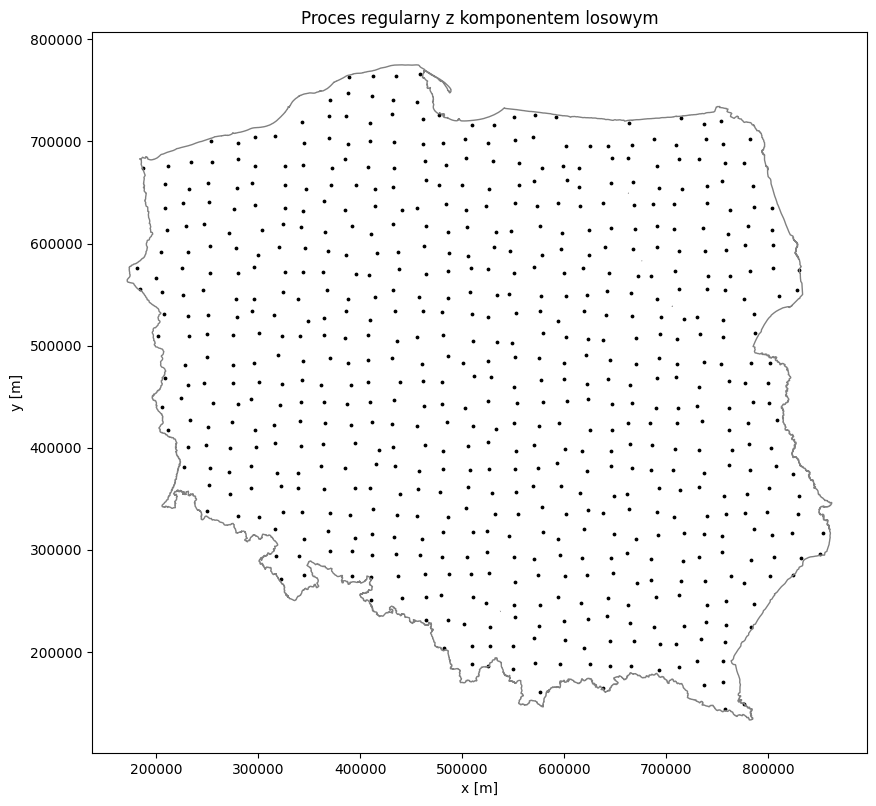

In [24]:
# Komórka testowa
points_R = regular_pp(poland.geometry[0], crs=2180, grid=[30, 30], random_component=0.5)

fig, ax = plt.subplots(1, 1, figsize=(10,10), facecolor="white")
points_R.plot(ax=ax, color="black", markersize=3)
poland.boundary.plot(ax=ax, color="grey", linewidth=1)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Proces regularny z komponentem losowym")

assert type(points_R) == gpd.geodataframe.GeoDataFrame
assert points_R.shape[1] == 1
assert list(points_R.columns) == ['geometry']
assert points_R.crs == "epsg:2180"
assert len(points_R) == len(points_R[points_R.within(poland.geometry[0])])

### Zadanie 2: Jednorodny proces punktowy Poissona [7 pkt]

Przygotuj funkcję `homogeneous_poisson_pp()`, która będzie generować jednorodny proces punktowy Poissona w obrębie zadanego poligonu.

Algorytm postępowania:
1. Za pomocą własności `shapely.geometry.polygon.Polygon.bounds` odczytaj zakres współrzędnych poligonu, w obrębie którego ma być wygenerowany rozkład.

2. Korzystając z odczytanych zakresów współrzędnych oblicz pole powierzchni prostokąta obejmującego poligon.

3. Korzystając z rozkładu Poissona o wartości oczekiwanej równej iloczynowi intensywności procesu i pola prostokąta (obszar, na którym będą generowane punkty) wylosuj liczbę punktów do wygenerowania $n$. 
   Użyj funkcji `scipy.stats.uniform.rvs()` lub `numpy.random.poisson()`.

4. Korzystając z rozkładów jednostajnych na przedziale równym zakresowi współrzędnych obszaru na danej osi wygeneruj zestawy $n$ losowych współrzędnych $x$ i $y$ punktów w obrębie prostokąta ograniczającego poligon. Użyj `scipy.stats.uniform.rvs()` lub `numpy.random.rand()` do wygenerowania współrzędnych, jeśli to niezbędne odpowiednio przeskaluj wartości.

5. Utwórz geometrię punktową za pomocą funkcji `geopandas.points_from_xy()` na podstawie przygotowanych współrzędnych.

6. Zbuduj obiekt `geopandas.GeoDataFrame`, ustawiając kolumnę geometrii oraz przypisując właściwy układ odniesienia.

7. Skorzystaj z funkcji `geopandas.GeoSeries.within()` w celu odfiltrowania punktów znajdujących się poza obszarem poligonu. Pamiętaj o zresetowaniu indeksów wynikowej tablicy.

8. Zwróć tablicę zawierającą punkty położone wewnątrz poligonu.

In [27]:
def homogeneous_poisson_pp(polygon, crs, intensity):
    """
    Parameters
    -------
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego mają zostać wygenerowane punkty.
    crs: str, int, pyproj.crs.crs.CRS
        Układ odniesienia przypisany do wynikowego GeoDataFrame. Powinien odpowiadać układowi współrzędnych wejściowego poligonu.
    intensity: float
        Liczba dodatnia określająca intensywność procesu punktowego.

    Returns
    -------
    points : geopandas.GeoDataFrame
        Tablica zawierająca punkty w układzie odniesienia `crs`, ograniczone wyłącznie do obszaru wejściowego poligonu.
    """
    minx, miny, maxx, maxy = polygon.bounds

    area = (maxx - minx)*(maxy - miny)

    n = np.random.poisson(intensity*area)

    x_rand = np.random.rand(n)*(maxx - minx) + minx
    y_rand = np.random.rand(n)*(maxy - miny) + miny

    XY = gpd.points_from_xy(x_rand, y_rand)

    GPD = gpd.GeoDataFrame(geometry=XY, crs=crs)

    mask = GPD.within(polygon)

    df = GPD[mask].reset_index(drop=True)

    return df

    

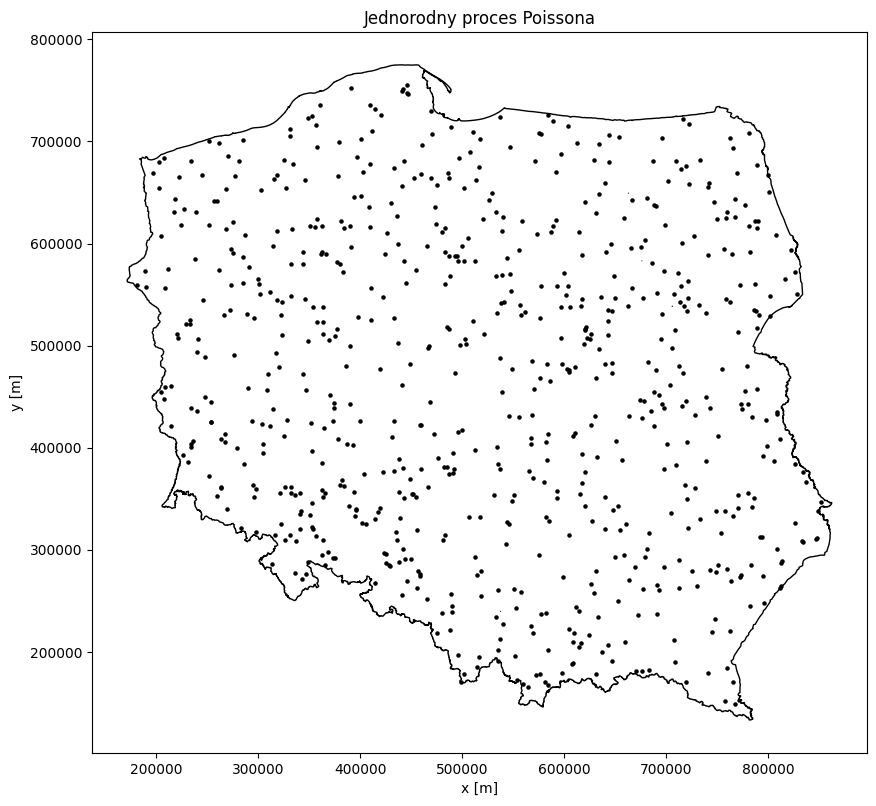

In [28]:
# Komórka testowa
points_P = homogeneous_poisson_pp(poland.geometry[0], crs=2180, intensity=0.0000000025)

fig, ax = plt.subplots(1, 1, figsize=(10,10), facecolor="white")

points_P.plot(ax=ax, color="black", markersize=5)
poland.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Jednorodny proces Poissona")

assert type(points_P) == gpd.geodataframe.GeoDataFrame
assert points_P.shape[1] == 1
assert list(points_P.columns) == ['geometry']
assert points_P.crs == "epsg:2180"
assert len(points_P) == len(points_P[points_P.within(poland.geometry[0])])

### Zadanie 3: Proces punktowy Matérna [7 pkt]

Przygotuj funkcję `materna_pp()`, która będzie generować proces punktowy Materna w obrębie zadanego poligonu.

Algorytm postępowania:

1. Na podstawie wejściowego poligonu utwórz obszar macierzysty dla procesu rodzicielskiego, poszerzając poligon o wartość równą promieniowi klastra `cluster_radius`. Użyj funkcji `shapely.geometry.polygon.Polygon.buffer()`.

2. Wygeneruj punkty macierzyste (parent points) zgodnie z jednorodnym procesem Poissona o intensywności `parent_intensity` w utworzonym obszarze macierzystym. Skorzystaj z wcześniej przygotowanej funkcji `homogeneous_poisson_pp()`.

3. Dla każdego punktu macierzystego utwórz obszar klastra (cluster area), buforując dany punkt o promień równy promieniowi klastra `cluster_radius`. Użyj funkcji `geopandas.GeoSeries.buffer()`.

4. Dla każdego punktu macierzystego wygeneruj punkty potomne (daughter points). W tym celu przeiteruj w pętli `for` po kolejnych obszarach klastrów. Dla każdego z nich wygeneruj punkty potomne, stosując jednorodny proces Poissona o intensywności `daughter_intensity`. Skorzystaj z wcześniej przygotowanej funkcji `homogeneous_poisson_pp()`.

5. Zbierz otrzymane tablice danych w liście, a po zakończeniu pętli połącz je w całość z wykorzystaniem funkcji `pandas.concat()`.

6. Odfiltruj wszystkie punkty potomne znajdujące się poza właściwym poligonem wejściowym, korzystając z metody `geopandas.GeoSeries.within()`. Pamiętaj o zresetowaniu indeksów wynikowej tablicy.

7. Zwróć tablicę zawierającą wyłącznie punkty położone w obrębie wejściowego poligonu.


Uwagi do wykonania zadania:
- Punkty wygenerowane w ramach procesu macierzystego (centra klastrów) nie są częścią wynikowego rozkładu punktów.
- W części zadania dotyczącej generowania jednorodnego procesu punktowego Poissona nie należy dublować kodu napisanego w ramach zadania 2, a jedynie wywołać przygotowaną w ramach tego zadania funkcję `homogeneous_poisson_pp()`.

In [48]:
def materna_pp(polygon, crs, parent_intensity, daughter_intensity, cluster_radius):
    """
    Parameters
    -------
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego mają zostać wygenerowane punkty.
    crs: str, int, pyproj.crs.crs.CRS
        Układ odniesienia przypisany do wynikowego GeoDataFrame. Powinien odpowiadać układowi współrzędnych wejściowego poligonu.
    parent_intensity: float
        Liczba dodatnia określająca intensywność macierzystego procesu punktowego.
    daughter_intensity: float
        Liczba dodatnia określająca intensywność potomnego procesu punktowego.
    cluster_radius: float
        Liczba dodatnia określająca promień generowanych klastrów.

    Returns
    -------
    points : geopandas.GeoDataFrame
        Tablica zawierająca punkty w układzie odniesienia `crs`, ograniczone wyłącznie do obszaru wejściowego poligonu.
    """

    ob_macierzysty = polygon.buffer(distance=cluster_radius)

    p_macierzyste = homogeneous_poisson_pp(polygon, crs, parent_intensity)

    ob_klastra = p_macierzyste.buffer(distance=cluster_radius)

    punkty = []
    for i in ob_klastra:
        p_pot = homogeneous_poisson_pp(i, crs, daughter_intensity)
        punkty.append(p_pot)

    pkt = pd.concat(punkty)

    mask = pkt.within(polygon)

    df = pkt[mask].reset_index(drop=True)

    return df

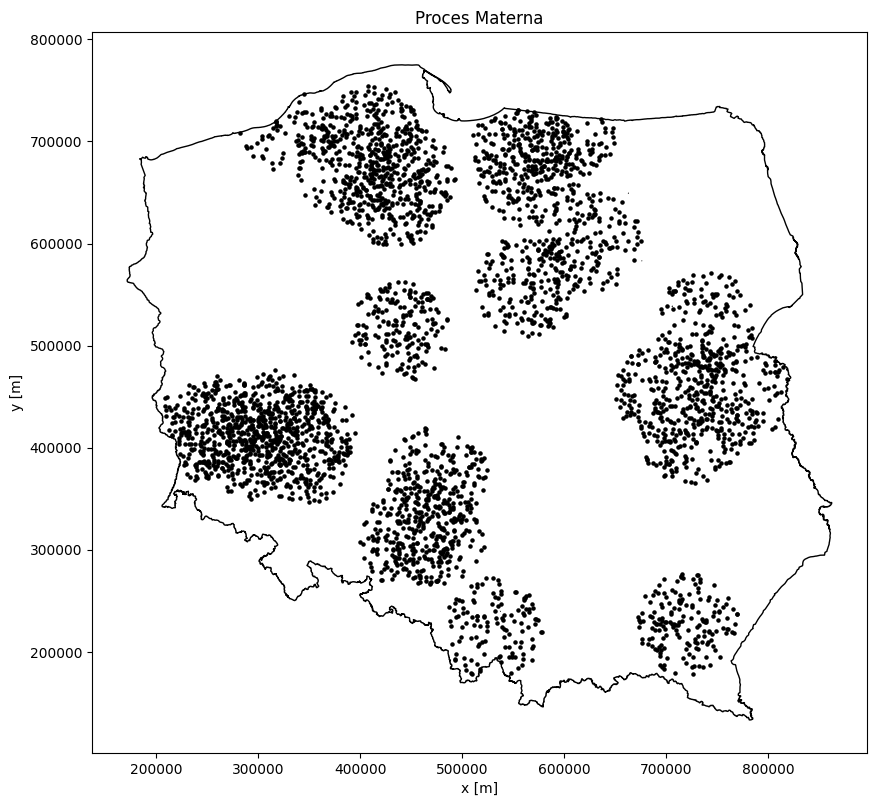

In [49]:
# Komórka testowa
points_M = materna_pp(poland.geometry[0], crs=2180, parent_intensity=0.000000000075, daughter_intensity=0.00000002, cluster_radius=50000)

fig, ax = plt.subplots(1, 1, figsize=(10,10), facecolor="white")
points_M.plot(ax=ax, color="black", markersize=5)
poland.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Proces Materna")

assert type(points_M) == gpd.geodataframe.GeoDataFrame
assert points_M.shape[1] == 1
assert list(points_M.columns) == ['geometry']
assert points_M.crs == "epsg:2180"
assert len(points_M) == len(points_M[points_M.within(poland.geometry[0])])

### Zadanie 4: Proces punktowy Thomas [7 pkt]

Przygotuj funkcję `thomas_pp()`, która będzie generować proces punktowy Thomas w obrębie zadanego poligonu.

Algorytm postępowania:

1. Na podstawie wejściowego poligonu utwórz obszar macierzysty dla procesu rodzicielskiego, poszerzając poligon o wartość równą wielokrotności odchylenia standardowego klastra (na potrzeby zadania przyjmij `4 * cluster_sigma`). Użyj funkcji `shapely.geometry.polygon.Polygon.buffer()`.

2. Wygeneruj punkty macierzyste (parent points) zgodnie z jednorodnym procesem Poissona o intensywności `parent_intensity` w utworzonym obszarze macierzystym.  
   Skorzystaj z funkcji `homogeneous_poisson_pp()`.

3. Dla każdego punktu macierzystego wygeneruj punkty potomne (daughter points). W tym celu przeiteruj w pętli `for` po kolejnych punktach macierzystych.  
   Dla każdego punktu macierzystego:

   - Korzystając z rozkładu Poissona o wartości oczekiwanej `mean_cluster_size` wylosuj unikalną liczbę punktów potomnych.  
     Użyj `scipy.stats.poisson.rvs()` lub `numpy.random.poisson()`.

   - Wygeneruj współrzędne punktów potomnych, korzystając z dwuwymiarowego rozkładu normalnego:  
     - współrzędne `x` losuj z rozkładu normalnego o wartości oczekiwanej równej współrzędnej `x` punktu macierzystego oraz odchyleniu standardowym równym `cluster_sigma`,  
     - współrzędne `y` losuj z rozkładu normalnego o wartości oczekiwanej równej współrzędnej `y` punktu macierzystego oraz odchyleniu standardowym równym `cluster_sigma`.  
     Skorzystaj z `scipy.stats.norm.rvs()` lub `numpy.random.normal()`.

   - Utwórz geometrię punktową dla punktów potomnych za pomocą `geopandas.points_from_xy()`.

   - Zbuduj obiekt `geopandas.GeoDataFrame`, ustawiając kolumnę geometrii oraz przypisując właściwy układ odniesienia.

4. Zbierz otrzymane tablice danych w liście, a po zakończeniu pętli połącz je w całość z wykorzystaniem funkcji `pandas.concat()`.

5. Odfiltruj wszystkie punkty potomne znajdujące się poza właściwym poligonem wejściowym, korzystając z metody `geopandas.GeoSeries.within()`. Pamiętaj o zresetowaniu indeksów wynikowej tablicy.

6. Zwróć tablicę zawierającą wyłącznie punkty położone w obrębie wejściowego poligonu.


Uwagi do wykonania zadania:
- Punkty wygenerowane w ramach procesu macierzystego (centra klastrów) nie są częścią wynikowego rozkładu punktów.
- W części zadania dotyczącej generowania jednorodnego procesu punktowego Poissona nie należy dublować kodu napisanego w ramach zadania 2, a jedynie wywołać przygotowaną w ramach tego zadania funkcję `homogeneous_poisson_pp()`.



In [66]:
def thomas_pp(polygon, crs, parent_intensity, mean_cluster_size, cluster_sigma):
    """
    Parameters
    -------
    polygon: shapely.geometry.polygon.Polygon
        Geometria poligonu, w obrębie którego mają zostać wygenerowane punkty.
    crs: str, int, pyproj.crs.crs.CRS
        Układ odniesienia przypisany do wynikowego GeoDataFrame. Powinien odpowiadać układowi współrzędnych wejściowego poligonu.
    parent_intensity: float
        Liczba dodatnia określająca intensywność macierzystego procesu punktowego.
    daughter_intensity: float
        Liczba dodatnia określająca intensywność potomnego procesu punktowego.
    cluster_sigma: float
        Liczba dodatnia określająca stopień rozproszenia punktów w obrębie klastra.

    Returns
    -------
    points : geopandas.GeoDataFrame
        Tablica zawierająca punkty w układzie odniesienia `crs`, ograniczone wyłącznie do obszaru wejściowego poligonu.
    """
    
    ob_macierzysty = polygon.buffer(distance=4*cluster_sigma)

    parent_pkt = homogeneous_poisson_pp(polygon, crs, parent_intensity)

    lista = []
    for i in parent_pkt.geometry:
        n = np.random.poisson(mean_cluster_size)
        x = np.random.normal(i.x, cluster_sigma, n)
        y = np.random.normal(i.y, cluster_sigma, n)
        geom = gpd.points_from_xy(x,y)
        GPD = gpd.GeoDataFrame(geometry=geom, crs=crs)
        lista.append(GPD)

    pkt = pd.concat(lista)

    mask = pkt.within(polygon)

    df = pkt[mask].reset_index(drop=True)

    return df
    

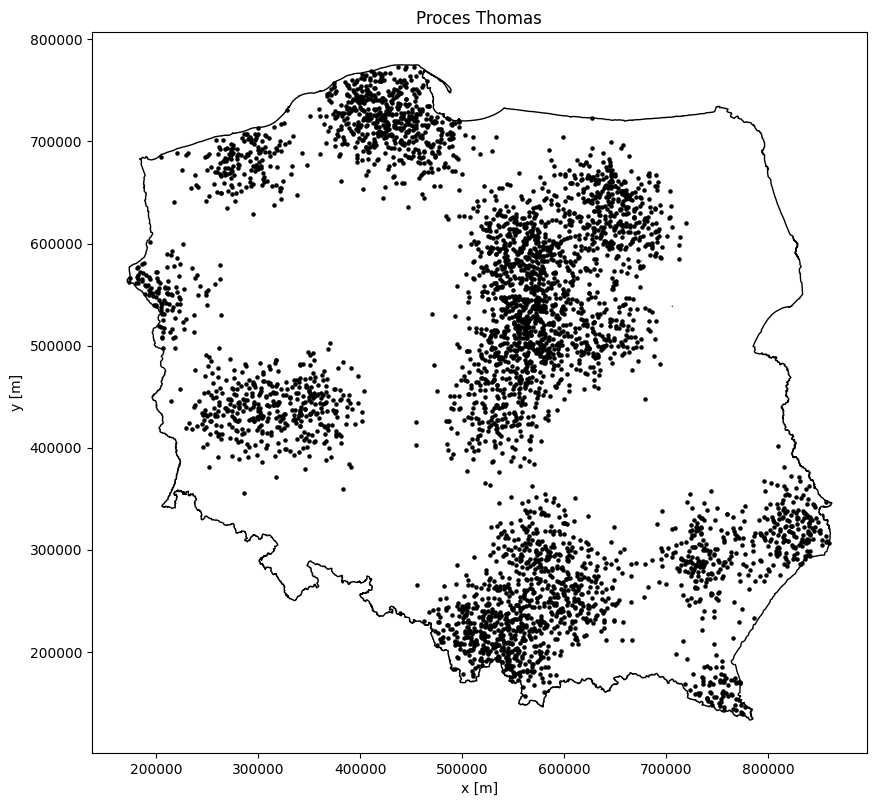

In [67]:
# Komórka testowa
points_T = thomas_pp(poland.geometry[0], crs=2180, parent_intensity=0.000000000075, mean_cluster_size=200, cluster_sigma=25000)

fig, ax = plt.subplots(1, 1, figsize=(10,10), facecolor="white")
points_T.plot(ax=ax, color="black", markersize=5)
poland.boundary.plot(ax=ax, color="black", linewidth=1)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Proces Thomas")

assert type(points_T) == gpd.geodataframe.GeoDataFrame
assert points_T.shape[1] == 1
assert list(points_T.columns) == ['geometry']
assert points_T.crs == "epsg:2180"
assert len(points_T) == len(points_T[points_T.within(poland.geometry[0])])